## TSNE-Comparison

### Imports and MNIST-1D embedding

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from mnist1d.data import get_dataset_args, make_dataset

In [8]:
dataset = make_dataset(get_dataset_args())

In [10]:
n_sub = 1500
rng   = np.random.default_rng(0)
idx   = rng.choice(len(dataset['x']), size=min(n_sub, len(dataset['x'])), replace=False)
x_1d, y_1d = dataset['x'][idx], dataset['y'][idx] 

In [11]:
tsne_1d = TSNE(n_components=2, random_state=0, init='pca')
emb_1d  = tsne_1d.fit_transform(x_1d)
print("MNIST-1D embedding:", emb_1d.shape)

MNIST-1D embedding: (1500, 2)


### Shared plotting helpers

In [12]:
def plot_embedding(ax, emb, labels, title):
    scatter = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab10', s=8, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return scatter


In [14]:
mnist_available = True
try:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')
    x_mnist_full = mnist.data
    y_mnist_full = mnist.target.astype(int)
except Exception as e:
    mnist_available = False
    print(f"Could not fetch real MNIST ({e}); skipping the real-MNIST panel.")

if mnist_available:
    idx2 = rng.choice(len(x_mnist_full), size=min(n_sub, len(x_mnist_full)), replace=False)
    x_mnist, y_mnist = x_mnist_full[idx2], y_mnist_full[idx2]
    tsne_mnist = TSNE(n_components=2, random_state=0, init='pca')
    emb_mnist = tsne_mnist.fit_transform(x_mnist)
    print("Real MNIST embedding:", emb_mnist.shape)


Real MNIST embedding: (1500, 2)


## Comparisons

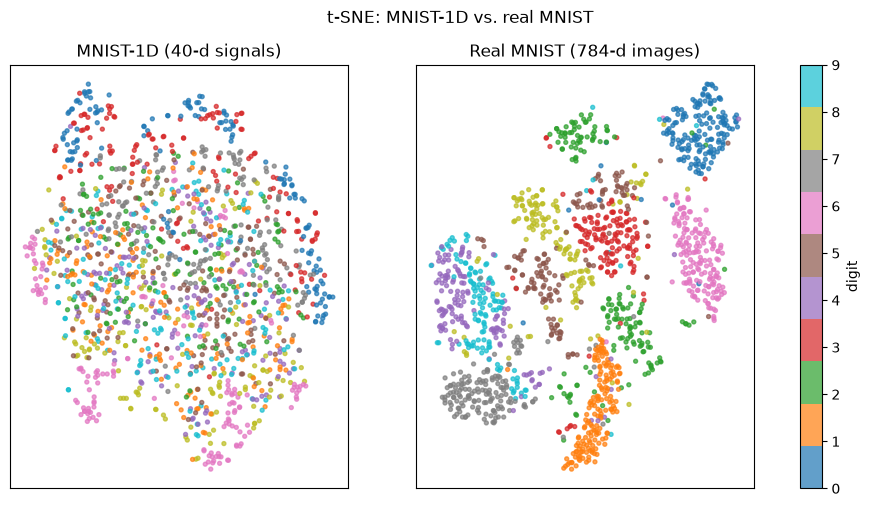

In [15]:
if mnist_available:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    plot_embedding(axes[0], emb_1d, y_1d, "MNIST-1D (40-d signals)")
    sc = plot_embedding(axes[1], emb_mnist, y_mnist, "Real MNIST (784-d images)")
else:
    fig, ax = plt.subplots(figsize=(6, 5.5))
    sc = plot_embedding(ax, emb_1d, y_1d, "MNIST-1D (40-d signals)")
    axes = [ax]

fig.colorbar(sc, ax=axes, label="digit", ticks=range(10))
plt.suptitle("t-SNE: MNIST-1D vs. real MNIST")
plt.show()
